In [265]:
import sys
from pathlib import Path

# add parent folder to python path
sys.path.append(str(Path.cwd().parent))

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [267]:
import os
import json
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np
from utils import   show_images
from tqdm import tqdm
from data_handlers.datasets import UDAFrameDataset
from utils.file_management import serialize_config,get_version_folder
from utils.augmentation import Augmentations
from model import EncoderDecoder
import torchvision.utils as vutils


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# binary_mask = torch.load('cache/utils/binary_mask.pt').to(device)

In [268]:
root = 'cache/model_weights/supplementary_vector'
index_folder = get_version_folder(root)

In [269]:
config= {
    'lr': 1e-4,
    'epochs': 10,
    'batch_size' : 32,
    'transformations' :None,
    'model_path':os.path.join(index_folder,'model.pt'),
    'samples_path':os.path.join(index_folder,'samples'),
    'bottleneck_dim':128,
    'number_of_frames':1,
    'number_of_vectors':8,
    'vectorizers_mat_mul':[True,True,False],#[True,True,True,True,False],
    'add_checkboard':False
}

config_json= serialize_config(config)
with open(os.path.join(index_folder,'config.json'),'w') as f:
    json.dump(config_json,f,indent=2)
os.mkdir(config['samples_path'])

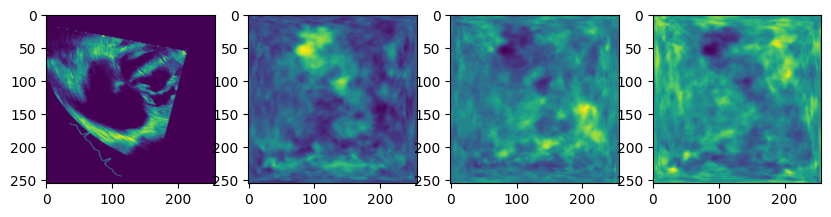

In [270]:
model = EncoderDecoder(bottleneck_dim=config['bottleneck_dim'],
                        number_of_vectors = config['number_of_vectors'],
                        vectorizers_mat_mul=  config['vectorizers_mat_mul'],
                        save_path = config['model_path']).to(device)

                 
optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])

dataset = UDAFrameDataset(number_of_frames=config['number_of_frames'])
train_loader = torch.utils.data.DataLoader(dataset, batch_size=config['batch_size'], shuffle=True)

losses =[]

augmentations = Augmentations( degrees=30,
                                translate=(0.0, 0.3),
                                scale=(0.9, 1.1),
                                shear=15,
                                add_checkboard=config['add_checkboard'])
data = next(iter(train_loader))
data = augmentations(data)
data = data.to(device)[:,0]
with torch.no_grad():
    rec,seg= model(data)


components = rec.shape[1]
fig,ax = plt.subplots(1,components+1,figsize=(10,5))
ax[0].imshow(data.cpu().numpy()[0,0])
for i in range(components):
    ax[i+1].imshow(seg.cpu().numpy()[0,i])



In [ ]:
epochs  =10
for epoch in range(epochs):
    loop = tqdm(train_loader,desc=f'Epoch {epoch}/{epochs}')
    for data in loop:
        data = augmentations(data)
        optimizer.zero_grad()
        frame = data[:,0].to(device)    
        rec,seg= model(frame)
       
        heads = seg.shape[1]
        
        loss = 0
        overlap_loss =0
        for i in range(heads):
            for j in range(i+1,heads):
                overlap_loss += (1/heads**2)*(seg[:,i]*seg[:,j]).mean()
        overlap_loss = 20 * overlap_loss 

        reconstruction = torch.sum(seg*rec,dim=1).unsqueeze(1)
        recon_loss = 20*F.mse_loss(reconstruction,frame)
        for i in range(rec.shape[1]):
            recon_loss += 10*F.mse_loss(rec[:,i].unsqueeze(1),frame)


    
        bg_area_loss = 10 *torch.mean(seg[:,-1])
        # bg_area_loss = 0    
        loss = recon_loss #+ overlap_loss  #+bg_area_loss

    
        loop.set_postfix(recon_loss=recon_loss.item())
        loss.backward()
        optimizer.step()
        losses.append(loss.item()) 
        # loop.set_postfix(recon_loss=recon_loss.item(),overlap_loss=overlap_loss.item(),bg_area_loss=bg_area_loss.item())
    # # torch.save(model.state_dict(), model.save_path)
    # imgs_to_plot = torch.cat([
    #         data[:4,0].cpu(),           # Top row: Real
    #         seg[:4,:1].cpu(),  # Middle row: Reconstructed
    #         seg[:4,1:].cpu()        
    # ], dim=0)
        
        
    # # Create a grid natively on the tensσors
    # grid = vutils.make_grid(imgs_to_plot, nrow=4)

    # # 1. Save to disk (replaces plt.savefig)
    # img_path = os.path.join(config['samples_path'],  f'{epoch}.png')
    # vutils.save_image(grid, img_path)

Epoch 0/10:   3%|▎         | 37/1179 [00:17<08:44,  2.18it/s, recon_loss=0.881]

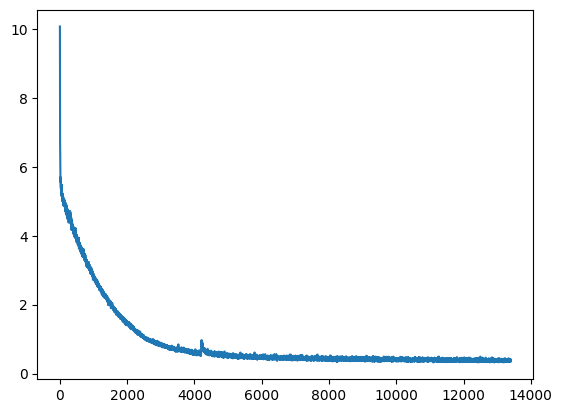

In [ ]:
plt.plot(losses)

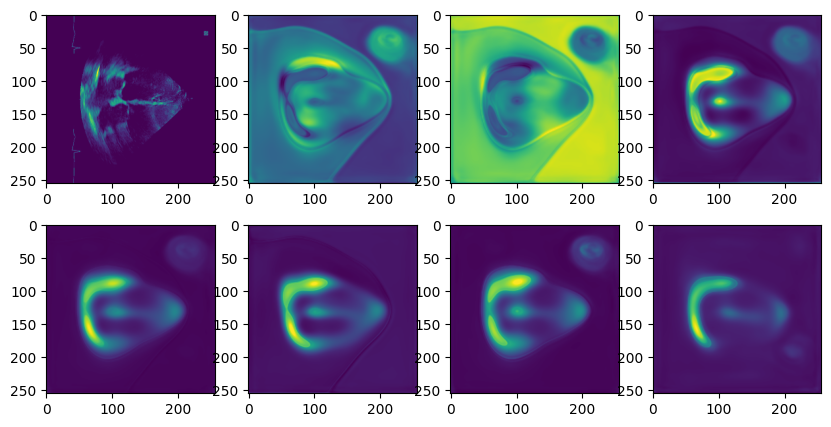

In [284]:
data = next(iter(train_loader))
data = augmentations(data,train=False)[:,0].to(device)
data = data.to(device)
with torch.no_grad():
    rec,seg= model(data)
    reconstruction = torch.sum(seg*rec,dim=1).unsqueeze(1)
components = rec.shape[1]
fig,ax = plt.subplots(2,components+1,figsize=(10,5))
ax[0,0].imshow(data.cpu().numpy()[0,0])
for i in range(components):
    ax[0,i+1].imshow(seg.cpu().numpy()[0,i])


ax[1,0].imshow(reconstruction.cpu().numpy()[0,0])
for i in range(components):
    ax[1,i+1].imshow(rec.cpu().numpy()[0,i])
